In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split

# Lasoo Regularization/L1

This is a Regularization technique used in feature selection using a shrinkage method also referred to as the penalized regression method.

Lasso Regression magnitude of coefficients can be exactly zero. 

In [2]:
df = pd.read_csv('../../../../Dataset/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
cols_to_convert = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[cols_to_convert] = df[cols_to_convert].replace({'yes': True, 'no': False})
df.drop(columns='furnishingstatus', inplace=True)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,13300000,7420,4,2,3,True,False,False,False,True,2,True
1,12250000,8960,4,4,4,True,False,False,False,True,3,False
2,12250000,9960,3,2,2,True,False,True,False,False,2,True
3,12215000,7500,4,2,2,True,False,True,False,True,3,True
4,11410000,7420,4,1,2,True,True,True,False,True,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,True,False,True,False,False,2,False
541,1767150,2400,3,1,1,False,False,False,False,False,0,False
542,1750000,3620,2,1,1,True,False,False,False,False,0,False
543,1750000,2910,3,1,1,False,False,False,False,False,0,False


In [4]:
from sklearn.preprocessing import StandardScaler

<Axes: >

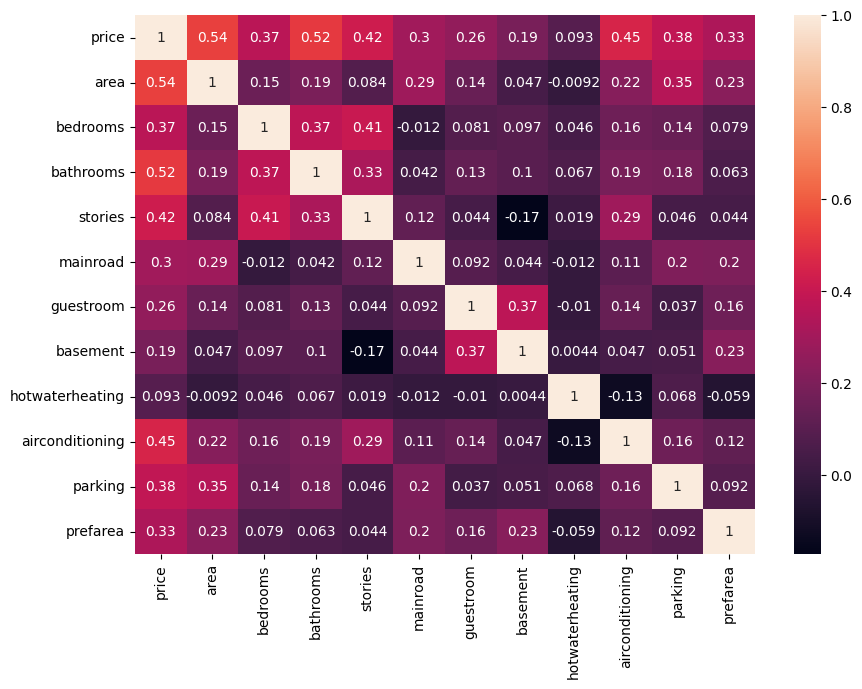

In [5]:
plt.figure(figsize=(10, 7))
sns.heatmap(data=df.corr(), annot=True)

In [6]:
x = df.iloc[:, 1:]
y = df.iloc[:, :1]

In [7]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns = x.columns)
x.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,1.046726,1.403419,1.421812,1.378217,0.405623,-0.465315,-0.734539,-0.219265,1.472618,1.517692,1.804941
1,1.757010,1.403419,5.405809,2.532024,0.405623,-0.465315,-0.734539,-0.219265,1.472618,2.679409,-0.554035
2,2.218232,0.047278,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,-0.679063,1.517692,1.804941
3,1.083624,1.403419,1.421812,0.224410,0.405623,-0.465315,1.361397,-0.219265,1.472618,2.679409,1.804941
4,1.046726,1.403419,-0.570187,0.224410,0.405623,2.149083,1.361397,-0.219265,1.472618,1.517692,-0.554035


In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

## Linear Regression vs Lasso Regression

### 1. Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test) * 100

65.49615837553934

In [11]:
print(mean_squared_error(y_test, lr.predict(x_test)))
print(mean_absolute_error(y_test, lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, lr.predict(x_test))))

1590022310748.239
918022.175308945
1260960.8680479499


In [12]:
lr.coef_.ravel() # .ravel() use for convert 2d to 1d

array([524300.29371626,  55539.71622156, 570262.34257549, 348731.65613386,
       144310.44415338, 109752.94436218, 210850.20135014, 152614.70408043,
       367710.15062599, 236552.13737795, 271583.68493506])

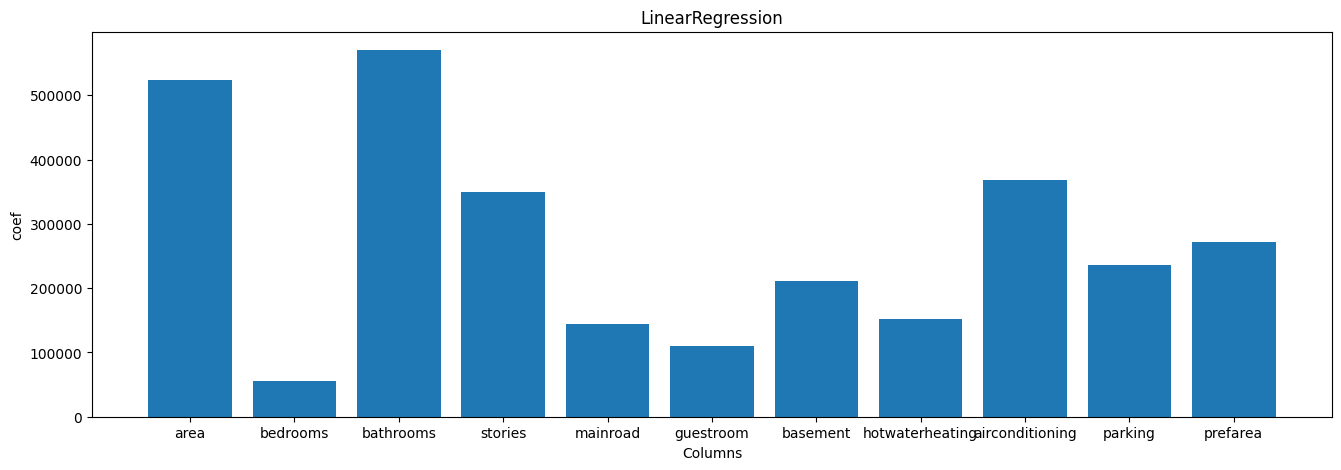

In [13]:
plt.figure(figsize=(16, 5))
plt.bar(x.columns, lr.coef_.ravel())
plt.title("LinearRegression")
plt.xlabel("Columns")
plt.ylabel("coef")
plt.show()

### 2. Lasso

In [14]:
la = Lasso(alpha=0.5)
la.fit(x_train, y_train)
la.score(x_test, y_test) * 100

65.49614728166182

In [15]:
print(mean_squared_error(y_test, la.predict(x_test)))
print(mean_absolute_error(y_test, la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, la.predict(x_test))))

1590022821981.5374
918022.2783670578
1260961.0707637002


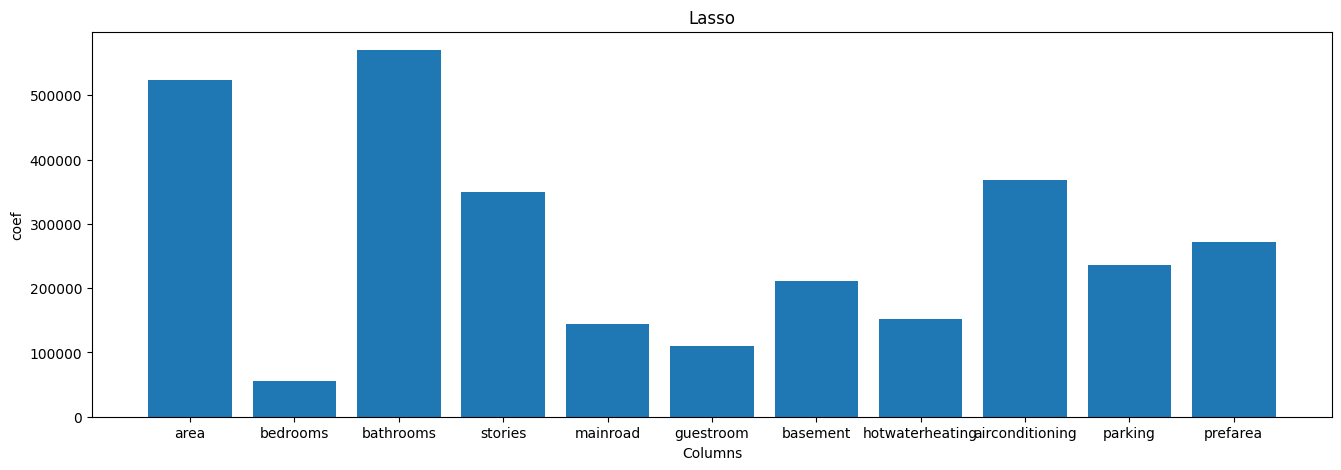

In [16]:
plt.figure(figsize=(16, 5))
plt.bar(x.columns, la.coef_.ravel())
plt.title("Lasso")
plt.xlabel("Columns")
plt.ylabel("coef")
plt.show()

In [17]:
dfa = pd.DataFrame({"col_name":x.columns, "LinearRegression":lr.coef_.ravel(), "Lasso":la.coef_.ravel()})
dfa

,col_name,LinearRegression,Lasso
0,area,524300.293716,524300.178373
1,bedrooms,55539.716222,55539.633474
2,bathrooms,570262.342575,570262.136061
3,stories,348731.656134,348731.313516
4,mainroad,144310.444153,144310.170183
5,guestroom,109752.944362,109752.750291
6,basement,210850.201350,210849.832644
7,hotwaterheating,152614.704080,152614.213917
8,airconditioning,367710.150626,367709.944565
9,parking,236552.137378,236551.886698
